# Compare unweighted and weighted SILVA classifications

In [1]:
import pandas as pd
import os

import tkinter as tk

import qiime2 as q2

%matplotlib inline

In [2]:
import os
import qiime2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the working directory
#wd = '/Users/meyeanni/Desktop/git_sourdough/SourdoughFlow/LP5/Citizen_reports/LP5_LP7_integration/SILVA/new_12.25'
wd = '/home/meyeanni/cloud/meyeanni/LP4/artifacts/16S/classifier_tests'
# Change to the working directory
os.chdir(wd)

# Verify current working directory
print("Current working directory:", os.getcwd())

Current working directory: /home/meyeanni/cloud/meyeanni/LP4/artifacts/16S/classifier_tests


In [3]:
from qiime2 import (Artifact,
                    Metadata as qmd)

from qiime2.plugins import (cutadapt,
                            demux,
                            feature_table as qft,
                            taxa as q2t,)

from qiime2 import Metadata
from qiime2 import Visualization

from qiime2.plugins.feature_table.methods import (merge_seqs, merge, filter_seqs, filter_samples, filter_features) 
import qiime2.plugins.feature_classifier.actions as feature_classifier_actions
import qiime2.plugins.metadata.actions as metadata_actions
import qiime2.plugins.taxa.actions as taxa_actions
import qiime2.plugins.phylogeny.actions as phylogeny_actions
from qiime2.plugins.fragment_insertion.methods import sepp

/home/meyeanni/miniconda3/envs/qiime2-amplicon-2025.7/lib/python3.10/site-packages/q2_demux/_summarize/_visualizer.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
pwd

'/home/meyeanni/cloud/meyeanni/LP4/artifacts/16S/classifier_tests'

In [5]:

import re
import qiime2
import numpy as np
import pandas as pd

RANKS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# map prefix -> target rank
PREFIX_TO_RANK = {
    "d": "Domain",
    "k": "Domain",   # treat k__ as Domain if no d__ present
    "p": "Phylum",
    "c": "Class",
    "o": "Order",
    "f": "Family",
    "g": "Genus",
    "s": "Species",
}

UNINFORMATIVE = {"", "unassigned", "unknown", "uncultured"}

def _split_tokens(taxon: str) -> list[str]:
    if taxon is None or pd.isna(taxon):
        return []
    return [t.strip() for t in str(taxon).split(";") if str(t).strip()]

def _parse_prefixed_token(tok: str):
    """
    Returns (prefix_letter, label) if token looks like 'd__Bacteria', 'D_0__Bacteria', 'k__Bacteria', etc.
    Otherwise returns (None, cleaned_label).
    """
    tok = tok.strip()

    # QIIME2 style: D_0__Bacteria, D_1__Firmicutes, ...
    m = re.match(r"^D_(\d+)__(.*)$", tok)
    if m:
        idx = int(m.group(1))
        label = m.group(2).strip()
        # Map D_0.. to canonical ranks by position
        # D_0 Domain, D_1 Phylum, D_2 Class, D_3 Order, D_4 Family, D_5 Genus, D_6 Species
        if 0 <= idx < len(RANKS):
            return ("D", idx, label)

    # Kraken/Greengenes style: d__ / k__ / p__ etc
    m = re.match(r"^([dkpcofgs])__(.*)$", tok)
    if m:
        pref = m.group(1)
        label = m.group(2).strip()
        return (pref, None, label)

    # No prefix
    return (None, None, tok)

def _clean_label(label: str | None) -> str | None:
    if label is None:
        return None
    lab = str(label).strip()
    if lab.lower() in UNINFORMATIVE:
        return None
    return lab

def parse_qiime_taxon_aligned(taxon: str, ranks=RANKS) -> dict:
    tokens = _split_tokens(taxon)

    # First pass: detect presence of d__ and k__
    has_d = any(re.match(r"^d__", t.strip()) for t in tokens)
    has_k = any(re.match(r"^k__", t.strip()) for t in tokens)

    out = {r: None for r in ranks}

    for t in tokens:
        pref, d_idx, label = _parse_prefixed_token(t)
        label = _clean_label(label)
        if label is None:
            continue

        # Handle D_0__... format by index
        if pref == "D" and d_idx is not None:
            out[ranks[d_idx]] = label
            continue

        # Handle letter prefixes (d__/k__/p__/...)
        if pref in PREFIX_TO_RANK:
            # If both d__ and k__ present, drop k__ entirely
            if pref == "k" and has_d and has_k:
                continue

            target_rank = PREFIX_TO_RANK[pref]
            out[target_rank] = label
            continue

        # If token had no prefix, do nothing (or you could add a fallback strategy)
        # Here we ignore unprefixed tokens to avoid misalignment.

    return out

def load_taxonomy_qza(path: str) -> pd.DataFrame:
    tax = qiime2.Artifact.load(path).view(pd.DataFrame).reset_index()
    tax.rename(columns={"index": "Feature ID"}, inplace=True)

    if "Confidence" not in tax.columns:
        tax["Confidence"] = tax['Consensus'] if 'Consensus' in tax.columns else np.nan
    tax["Confidence"] = pd.to_numeric(tax["Confidence"], errors="coerce")

    ranks_df = pd.DataFrame([parse_qiime_taxon_aligned(t) for t in tax["Taxon"]])
    out = pd.concat([tax[["Feature ID", "Taxon", "Confidence"]], ranks_df], axis=1)
    return out

def deepest_rank(row, ranks=RANKS) -> str:
    for r in reversed(ranks):
        v = row.get(r)
        if pd.notna(v) and v is not None and str(v).strip() != "":
            return r
    return "Unassigned"

def deepest_rank_depth(row, ranks=RANKS) -> int:
    dr = deepest_rank(row, ranks)
    return 0 if dr == "Unassigned" else (ranks.index(dr) + 1)


In [14]:
configs = [
    # SILVA sklearn
    {"name": "silva_sklearn",   "taxonomy_qza": "test_data/classifications/taxonomy_silva_conf0.qza"},
    #{"name": "silva_sklearn_c0.7", "taxonomy_qza": "test_data/classifications/taxonomy_silva_conf0.7.qza"},
    # SILVA blast
    #{"name": "silva_blast_0.97",   "taxonomy_qza": "test_data/classifications/taxonomy_silva_blast97.qza"},
    {"name": "silva_blast_0.99",   "taxonomy_qza": "test_data/classifications/taxonomy_silva_blast99_1.qza"},
    {"name": "silva_vsearch_99",    "taxonomy_qza": "test_data/classifications/taxonomy_silva_vsearch100.qza"},

#now add the average-weighted results:
    {"name": "silva_aw_sklearn",   "taxonomy_qza": "test_data/classifications/taxonomy_silva_average_weight_conf0.qza"},
    #{"name": "silva_aw_sklearn_c0.7", "taxonomy_qza": "test_data/classifications/taxonomy_silva_average_weight_conf0.7.qza"},
    # # NCBI ...
    # {"name": "ncbi_sklearn_c0",    "taxonomy_qza": "test_data/classifications/taxonomy_ncbi_conf0.qza"},
    # {"name": "ncbi_sklearn_c0.7",  "taxonomy_qza": "test_data/classifications/taxonomy_ncbi_conf0.7.qza"},

    # #{"name": "ncbi_blast_0.97",    "taxonomy_qza": "test_data/classifications/taxonomy_ncbi_blast97.qza"},
    # {"name": "ncbi_blast_0.99",    "taxonomy_qza": "test_data/classifications/taxonomy_ncbi_blast99_1.qza"},
    #     {"name": "ncbi_vsearch_99",    "taxonomy_qza": "test_data/classifications/taxonomy_ncbi_vsearch100.qza"},
]

tax_by_cfg = {}
for c in configs:
    df = load_taxonomy_qza(c["taxonomy_qza"])
    df["DeepestRank"] = df.apply(deepest_rank, axis=1)
    df["DeepestDepth"] = df.apply(deepest_rank_depth, axis=1)
    tax_by_cfg[c["name"]] = df

In [7]:
tax_by_cfg

{'silva_sklearn_c0':                          Feature ID  \
 0  734dab5c80beb33915fa168e328ad68f   
 1  60887f85cade99123e3a182351a7152f   
 2  3420507770c6d10a3672aeb8c6125f3f   
 3  c3f3cef7b4b014a4103e80d39a063f1d   
 4  d3240fa0af733487afe5c87fdc1e1591   
 5  a8b5ef29b07f0a54697d35a4473ef3b4   
 6  b250d27301547aede6c1d52ce67e6e2b   
 7  b2b9611993df71edaed52b3a3575a7de   
 
                                                Taxon  Confidence    Domain  \
 0  d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...    0.335274  Bacteria   
 1  d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...    0.707194  Bacteria   
 2  d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...    0.956018  Bacteria   
 3  d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...    0.918236  Bacteria   
 4  d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...    0.995616  Bacteria   
 5  d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...    0.938221  Bacteria   
 6  d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...    0.802321

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

def taxonomy_matrix(tax_by_cfg, rank="Genus"):
    mats = []
    for name, df in tax_by_cfg.items():
        s = df.set_index("Feature ID")[rank].fillna("Unassigned")
        s.name = name
        mats.append(s)
    return pd.concat(mats, axis=1)

genus_mat = taxonomy_matrix(tax_by_cfg, rank="Genus")
species_mat = taxonomy_matrix(tax_by_cfg, rank="Species")

display(genus_mat)   # in notebook: quick check
display(species_mat)



,silva_sklearn_c0,silva_sklearn_c0.7,silva_blast_0.99,silva_vsearch_99,silva_aw_sklearn_c0,silva_aw_sklearn_c0.7
Feature ID,,,,,,
734dab5c80beb33915fa168e328ad68f,Acetobacter,Acetobacter,Acetobacter,Acetobacter,Acetobacter,Acetobacter
60887f85cade99123e3a182351a7152f,Pediococcus,Pediococcus,Pediococcus,Pediococcus,Pediococcus,Pediococcus
3420507770c6d10a3672aeb8c6125f3f,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus
c3f3cef7b4b014a4103e80d39a063f1d,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus
d3240fa0af733487afe5c87fdc1e1591,Furfurilactobacillus,Furfurilactobacillus,Furfurilactobacillus,Furfurilactobacillus,Furfurilactobacillus,Furfurilactobacillus
a8b5ef29b07f0a54697d35a4473ef3b4,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus,Fructilactobacillus
b250d27301547aede6c1d52ce67e6e2b,Levilactobacillus,Levilactobacillus,Lactiplantibacillus,Levilactobacillus,Levilactobacillus,Levilactobacillus
b2b9611993df71edaed52b3a3575a7de,Acetobacter,Acetobacter,Acetobacter,Acetobacter,Acetobacter,Acetobacter


,silva_sklearn_c0,silva_sklearn_c0.7,silva_blast_0.99,silva_vsearch_99,silva_aw_sklearn_c0,silva_aw_sklearn_c0.7
Feature ID,,,,,,
734dab5c80beb33915fa168e328ad68f,Acetobacter_pasteurianus,Unassigned,uncultured_bacterium,Acetobacter_cerevisiae,uncultured_bacterium,Unassigned
60887f85cade99123e3a182351a7152f,uncultured_bacterium,uncultured_bacterium,uncultured_bacterium,Pediococcus_parvulus,uncultured_bacterium,uncultured_bacterium
3420507770c6d10a3672aeb8c6125f3f,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis,uncultured_Bacillus,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis
c3f3cef7b4b014a4103e80d39a063f1d,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis,uncultured_Bacillus,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis
d3240fa0af733487afe5c87fdc1e1591,Lactobacillus_rossiae,Lactobacillus_rossiae,Lactobacillus_rossiae,Lactobacillus_rossiae,Lactobacillus_rossiae,Lactobacillus_rossiae
a8b5ef29b07f0a54697d35a4473ef3b4,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis,uncultured_Bacillus,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis,Lactobacillus_sanfranciscensis
b250d27301547aede6c1d52ce67e6e2b,Lactobacillus_brevis,Lactobacillus_brevis,uncultured_Lactobacillus,Lactobacillus_brevis,Lactobacillus_brevis,Lactobacillus_brevis
b2b9611993df71edaed52b3a3575a7de,Acetobacter_pasteurianus,Unassigned,uncultured_bacterium,Acetobacter_cerevisiae,uncultured_bacterium,Unassigned


In [19]:
pwd

'/home/meyeanni/cloud/meyeanni/LP4/artifacts/16S/classifier_tests'

In [9]:
#save those tables to tsv:
genus_mat.to_csv('test_data/classifications/stats/20251218_genus_matrix.tsv', sep='\t', index=True)
species_mat.to_csv('test_data/classifications/stats/20251218_species_matrix.tsv', sep='\t', index=True)

In [80]:
#export the rep_seqs from qiime:
rep_seqs.export_data('test_data/bacteria-seqs-filt-shipping-ASVs-380-fasta')
# Now the sequences are in 'test_data/bacteria-seqs-filt-shipping-ASVs-380-fasta/dna-sequences.fasta'


-->> 734dab5c80beb33915fa168e328ad68f	blast this manually:: 

TACGAAGGGGGCTAGCGTTGCTCGGAATGACTGGGCGGAAAGGGCGTGTAGGCGGTTTGTACAGTTAGATGTGAAATCCCCGGGCTTAACCTGGGAGCTGCATTTAATACGTGCAGACTAGAGTGTGAGAGAGGGTTGTGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCGGTGGCGAAGGCGGCAACCTGGCTCATTACTGACGCTGAGGCGCGAAAGCGTGGGGAGCAAACAGG

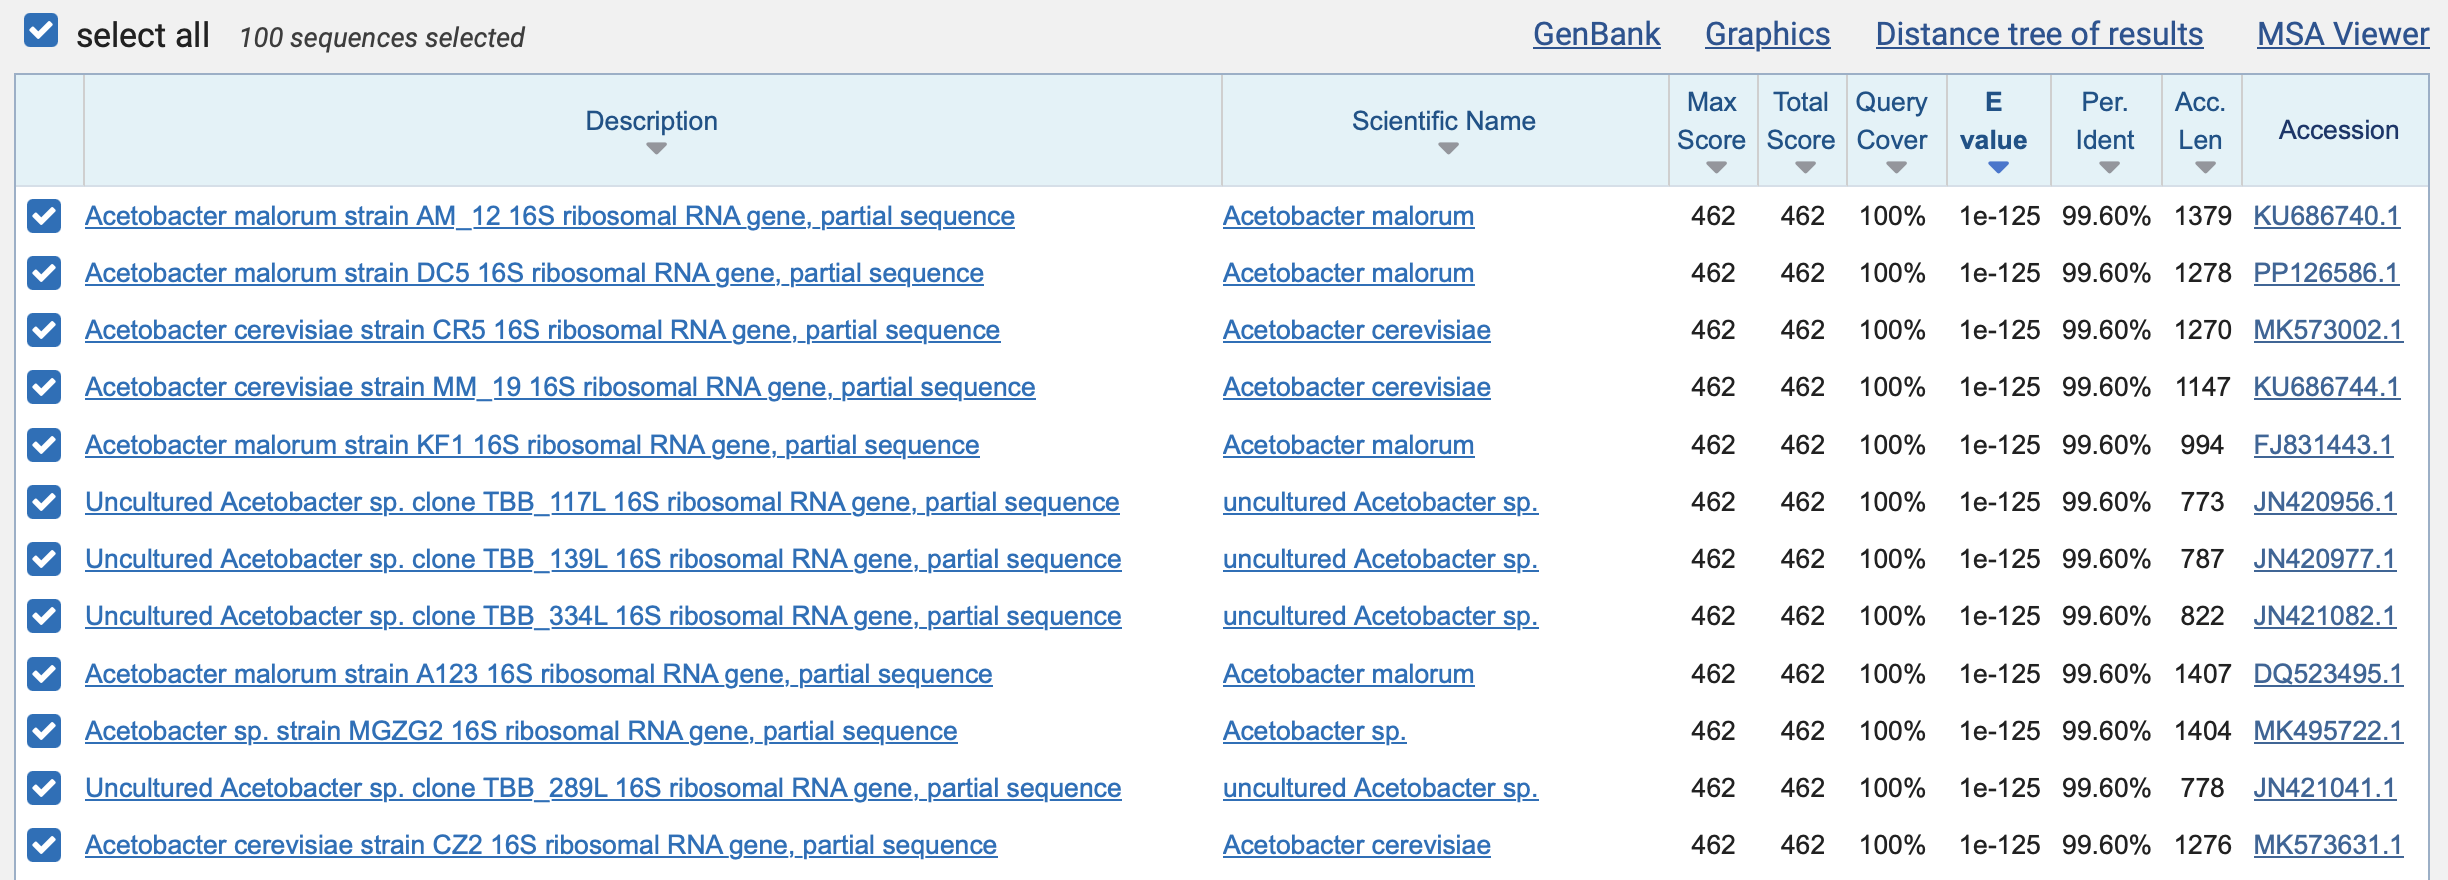


-->> also blast this here manually:

b2b9611993df71edaed52b3a3575a7de::

TACGAAGGGGGCTAGCGTTGCTCGGAATGACTGGGCGTAAAGGGCGTGTAGGCGGTTTGTACAGTTAGATGTGAAATCCCCGGGCTTAACCTGGGAGCTGCATTTAATACGTGCAGACTAGAGTGTGAGAGAGGGTTGTGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCGGTGGCGAAGGCGGCAACCTGGCTCATTACTGACGCTGAGGCGCGAAAGCGTGGGGAGCAAACAGG

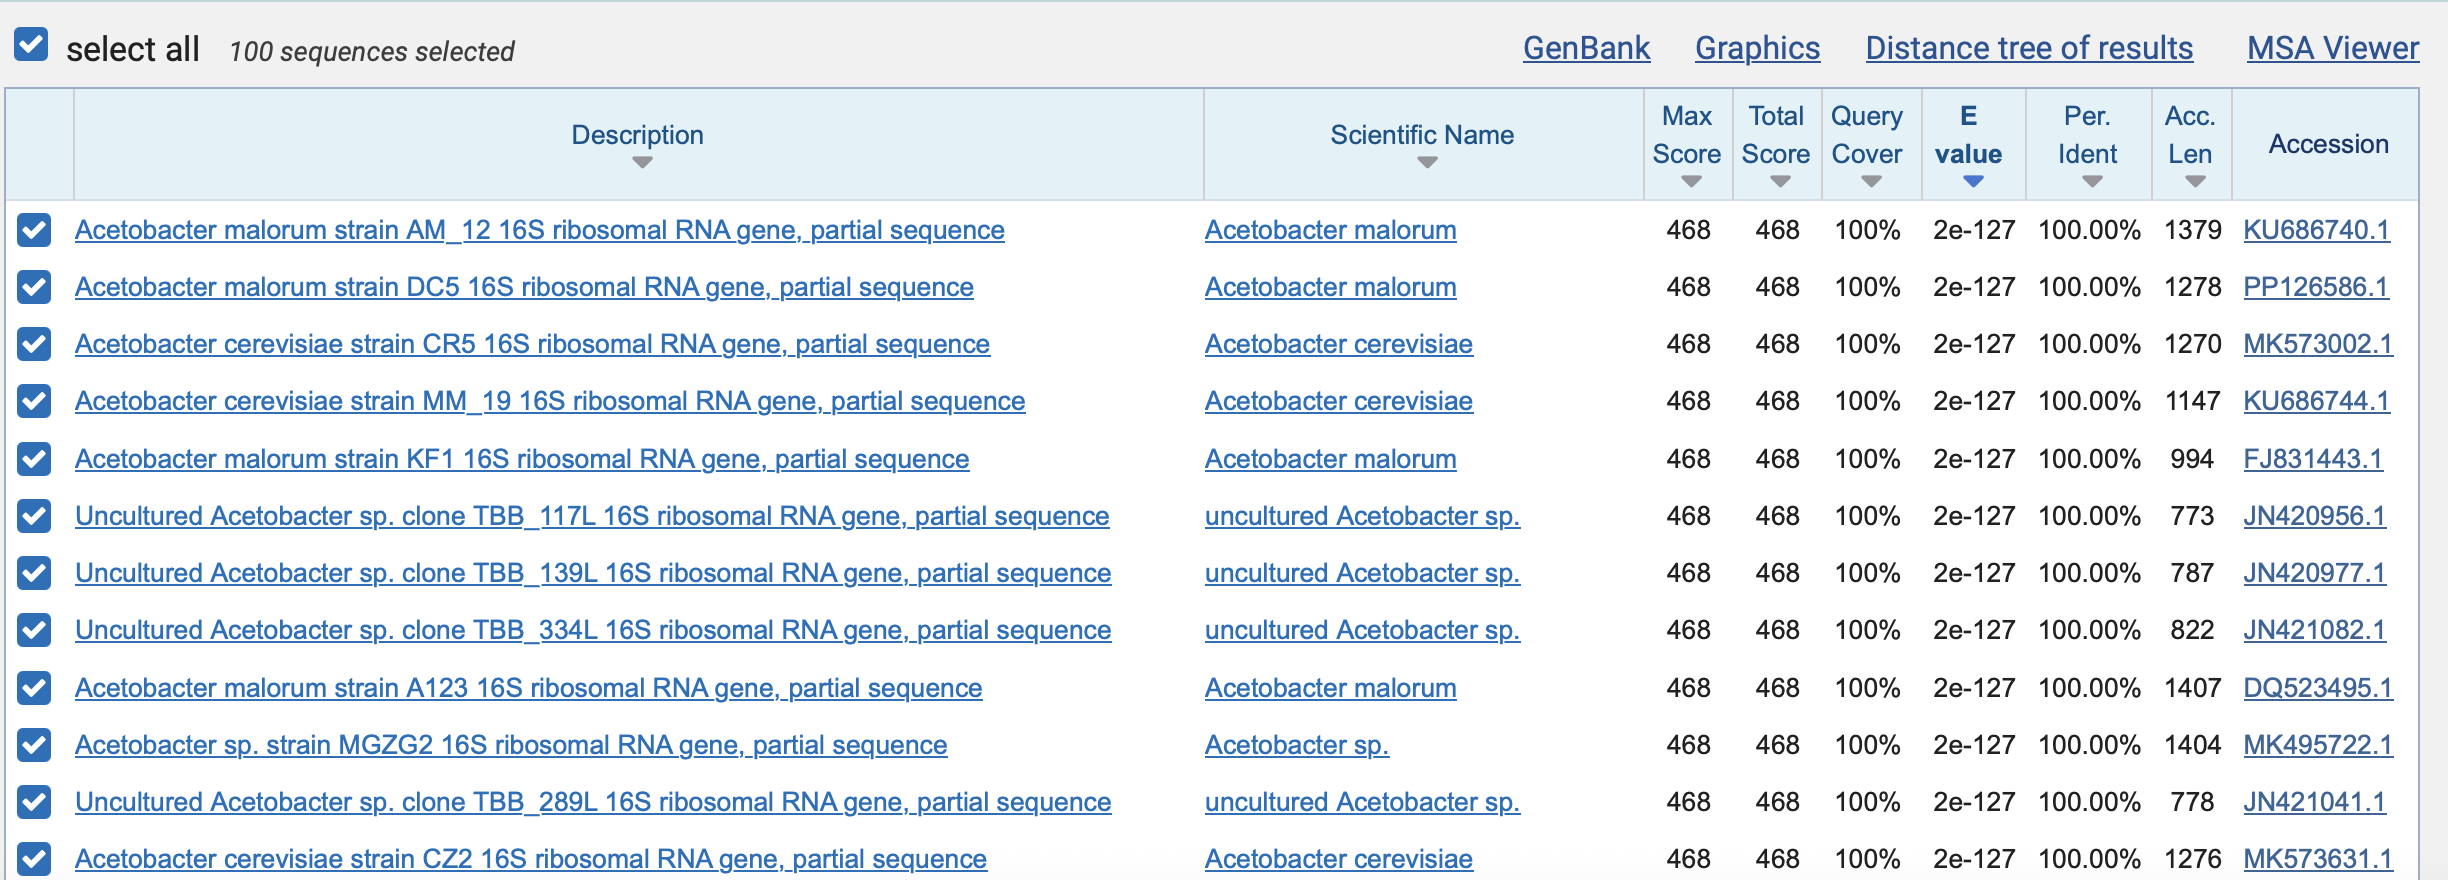


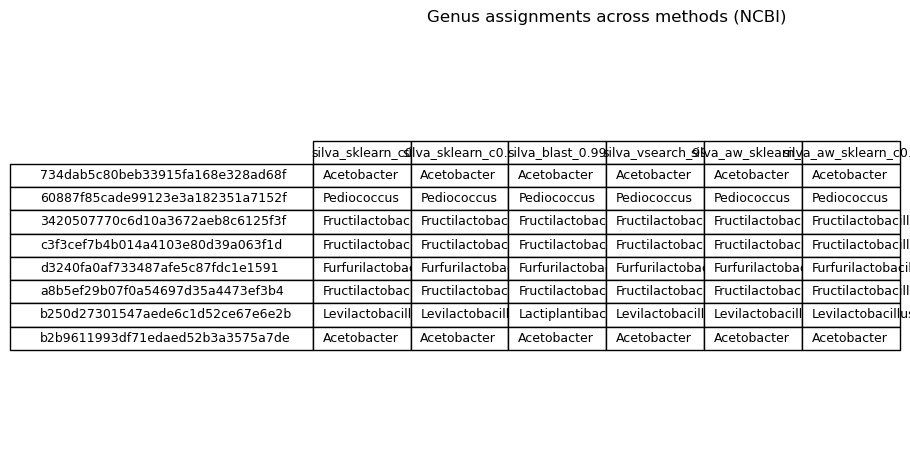

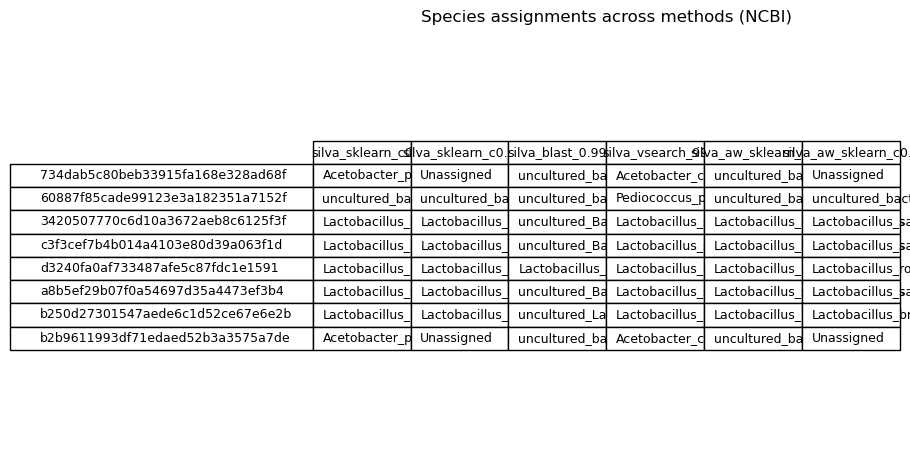

In [10]:
def plot_text_matrix(mat, title=""):
    fig, ax = plt.subplots(figsize=(1.2*mat.shape[1] + 2, 0.35*mat.shape[0] + 2))
    ax.axis("off")
    tbl = ax.table(
        cellText=mat.values,
        rowLabels=mat.index,
        colLabels=mat.columns,
        cellLoc="left",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.2)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_text_matrix(genus_mat, title="Genus assignments across methods (NCBI)")
plot_text_matrix(species_mat, title="Species assignments across methods (NCBI)")


In [11]:

cmap = ['#240E31FF', '#CB6BCEFF', '#468892FF', '#74F3D3FF', '#751C6DFF', '#FDC067FF', '#AC9ECEFF', '#6EC5ABFF']

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_asv_confidence_lines(tax_by_cfg, configs=("ncbi_sklearn_c0","ncbi_silva_sklearn_c0", "silva_sklearn_c0"),
                              title="ASV-level sklearn confidence"):
    if isinstance(configs, str):
        configs = [configs]

    dfs = []
    for cfg in configs:
        df = tax_by_cfg[cfg][["Feature ID", "Confidence"]].copy()

        # Force numeric confidence (strings -> floats); non-parsable -> NaN
        df["Confidence"] = pd.to_numeric(df["Confidence"], errors="coerce")

        df = df.set_index("Feature ID").rename(columns={"Confidence": cfg})
        dfs.append(df)

    wide = pd.concat(dfs, axis=1)

    # # Alphabetical ASV order
    # wide = wide.loc[sorted(wide.index)]
    #sort from highest to lowest confidence of first config
    wide = wide.sort_values(by=configs[0], ascending=False)


    # Clip safely (now numeric)
    wide = wide.clip(lower=0.0, upper=1.0)

    x = np.arange(len(wide.index))

    fig, ax = plt.subplots(figsize=(5, 5))
    for cfg in configs:
        ax.plot(x, wide[cfg].values, marker="o", linewidth=2, label=cfg, color=cmap[configs.index(cfg)%len(cmap)])

    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=45, ha="right", fontsize=14)
    
    ax.set_ylabel("Confidence", fontsize=14)
    ax.set_title(title, fontsize=16)

    # Force linear 0–1 axis
    ax.set_ylim(0, 1.2)
    ax.set_yticks(np.linspace(0, 1, 6))
    #make y axis labels larger
    ax.tick_params(axis='y', labelsize=14)

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    #despine upper and right axes

    #make a horiuonal line at y=0.7
    ax.axhline(y=0.7, color='black', linestyle='--', linewidth=1)

    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    #save the figure as pdf:
    plt.savefig(f'test_data/classifications/Figs/20251218_ASV_confidence_lines_{"_".join(configs)}.pdf', dpi=300, bbox_inches='tight')

    plt.show()



/scratch/meyeanni/tmp/ipykernel_1307016/2530697512.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


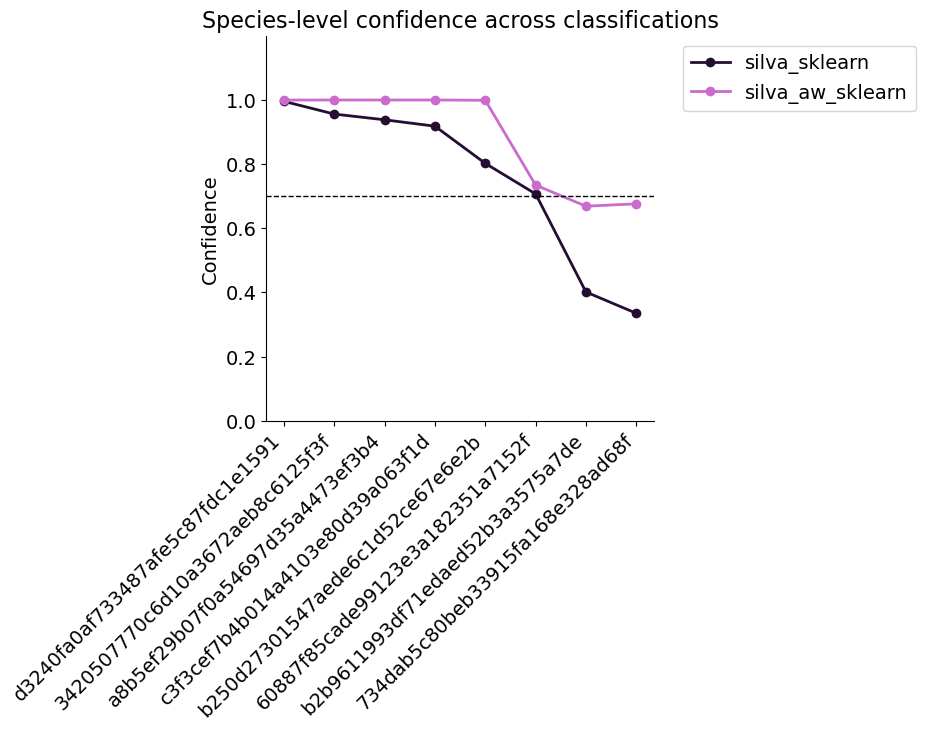

In [15]:
plot_asv_confidence_lines(
    tax_by_cfg,
    configs=[ "silva_sklearn", "silva_aw_sklearn"],
    title="Species-level confidence across classifications"
)

In [16]:
#show keys of tax_by_cfg
tax_by_cfg.keys()

dict_keys(['silva_sklearn', 'silva_blast_0.99', 'silva_vsearch_99', 'silva_aw_sklearn'])

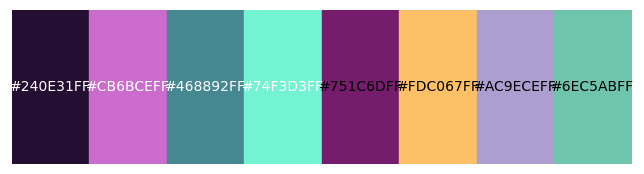

In [139]:
#plot colors of cmap
import matplotlib.pyplot as plt
def plot_cmap_colors(cmap):
    fig, ax = plt.subplots(figsize=(len(cmap), 2))
    for i, color in enumerate(cmap):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        ax.text(i + 0.5, 0.5, color, ha='center', va='center', color='white' if i < len(cmap)/2 else 'black')
    ax.set_xlim(0, len(cmap))
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.show()

plot_cmap_colors(cmap)

In [17]:
cmap

['#240E31FF',
 '#CB6BCEFF',
 '#468892FF',
 '#74F3D3FF',
 '#751C6DFF',
 '#FDC067FF',
 '#AC9ECEFF',
 '#6EC5ABFF']

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_taxa_confidence_bars_with_asv_dots(
    feature_table: pd.DataFrame,   # samples x ASVs (Feature IDs)
    tax_df: pd.DataFrame,          # from tax_by_cfg[cfg]
    rank: str = "Genus",
    topN: int = 10,
    sort_by: str = "abundance",    # keep as abundance
    bar_stat: str = "mean",        # currently only mean supported
    err: str = "sd",               # "sd" or "sem"
    weighted: bool = True,         # weight confidence by ASV total abundance
    dot_size_by_abundance: bool = True,
    jitter: float = 0.3,
    seed: int = 0,
    title: str = None,
    cfg_name: str = "unknown",
):
    # --- totals per ASV (across all samples) ---
    asv_total = feature_table.sum(axis=0)
    asv_total.name = "asv_total"

    # --- map ASV -> taxon + confidence ---
    m = tax_df.set_index("Feature ID")[[rank, "Confidence"]].copy()
    m[rank] = m[rank].fillna("Unassigned")
    m["Confidence"] = pd.to_numeric(m["Confidence"], errors="coerce")

    # align to table ASVs
    common = asv_total.index.intersection(m.index)
    if len(common) == 0:
        raise ValueError("No overlapping Feature IDs between feature_table and tax_df.")

    asv_total = asv_total.loc[common]
    m = m.loc[common]

    # drop unassigned and missing confidence for plotting confidence
    df = pd.DataFrame({
        "Feature ID": common,
        "taxon": m[rank].values,
        "confidence": m["Confidence"].values,
        "asv_total": asv_total.values
    })
    df = df[df["taxon"].ne("Unassigned")].copy()
    df = df.dropna(subset=["confidence"])

    # --- compute total abundance per taxon (for sorting & topN selection) ---
    tax_abundance = df.groupby("taxon")["asv_total"].sum().sort_values(ascending=False)
    top_taxa = tax_abundance.head(topN).index.tolist()
    df = df[df["taxon"].isin(top_taxa)].copy()

    # keep order by abundance
    taxa_order = tax_abundance.loc[top_taxa].index.tolist()

    # --- compute bar heights (mean confidence per taxon) ---
    bar_means = []
    bar_errs = []

    for taxon in taxa_order:
        sub = df[df["taxon"] == taxon]
        conf = sub["confidence"].to_numpy()
        w = sub["asv_total"].to_numpy()

        if weighted and w.sum() > 0:
            mean = np.average(conf, weights=w)
            # weighted SD / SEM (approx; adequate for visualization)
            var = np.average((conf - mean) ** 2, weights=w)
            sd = np.sqrt(var)
            sem = sd / np.sqrt(len(conf)) if len(conf) > 1 else 0.0
        else:
            mean = float(np.mean(conf)) if len(conf) else np.nan
            sd = float(np.std(conf, ddof=1)) if len(conf) > 1 else 0.0
            sem = sd / np.sqrt(len(conf)) if len(conf) > 1 else 0.0

        bar_means.append(mean)
        bar_errs.append(sd if err == "sd" else sem)

    x = np.arange(len(taxa_order))

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.bar(x, bar_means, yerr=bar_errs, capsize=3, alpha=0.6, color='#AC9ECEFF', edgecolor='none')

    # dots (ASVs)
    rng = np.random.default_rng(seed)
    for i, taxon in enumerate(taxa_order):
        sub = df[df["taxon"] == taxon].copy()
        xs = np.full(len(sub), i) + rng.uniform(-jitter, jitter, size=len(sub))
        ys = sub["confidence"].to_numpy()

        if dot_size_by_abundance:
            # scale dot sizes gently by abundance (avoid extreme sizes)
            s = sub["asv_total"].to_numpy()
            s = 20 + 80 * (s / s.max()) if s.max() > 0 else 40
            ax.scatter(xs, ys, s=s, alpha=0.9, color = '#751C6DFF')
        else:
            ax.scatter(xs, ys, alpha=0.9, color = '#751C6DFF')

    ax.set_xticks(x)
    ax.set_xticklabels(taxa_order, rotation=45, ha="right", fontsize=14, style='italic')
    ax.set_ylabel("Confidence", fontsize=14)
    ax.set_ylim(0, 1.2)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.tick_params(axis='y', labelsize=14)

    if title is None:
        wlab = "abundance-weighted" if weighted else "unweighted"
        elab = "SD" if err == "sd" else "SEM"
        title = f"{rank}: mean confidence ({wlab}) ± {elab}, taxa sorted by abundance"
    ax.set_title(title, fontsize=14)
    #despine upper and right axes
    sns.despine(ax=ax, top=True, right=True)
    #add a horizontal line at y=0.7
    ax.axhline(y=0.7, color='black', linestyle='--', linewidth=1)

    plt.tight_layout()
    #save as pdf:
    plt.savefig(f'test_data/classifications/Figs/20251218_top{topN}_{rank}_{cfg_name}_confidence_bars.pdf', dpi=300, bbox_inches='tight')
    plt.show()


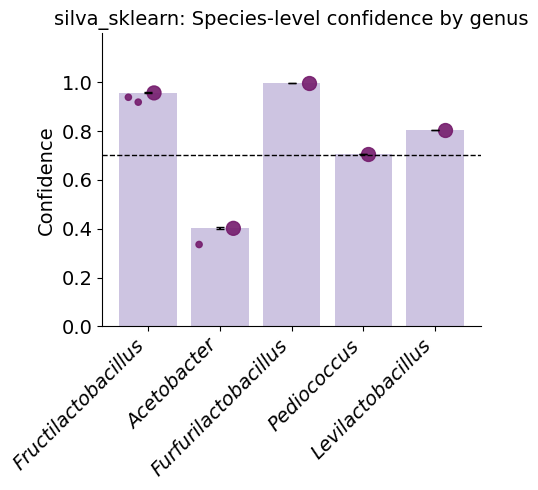

In [19]:
import qiime2
import pandas as pd

feature_table = qiime2.Artifact.load("test_data/filtered_table.qza").view(pd.DataFrame)

cfg = "silva_sklearn"
plot_top_taxa_confidence_bars_with_asv_dots(
    feature_table=feature_table,
    tax_df=tax_by_cfg[cfg],
    rank="Genus",
    topN=10,
    weighted=True,          # recommended: confidence summary reflects abundant ASVs
    err="sd",               # or "sem"
    title=f"{cfg}: Species-level confidence by genus",
    cfg_name=cfg
)


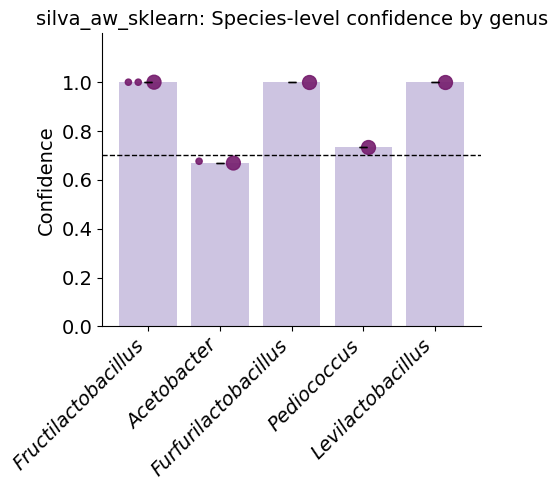

In [20]:
cfg = "silva_aw_sklearn"
plot_top_taxa_confidence_bars_with_asv_dots(
    feature_table=feature_table,
    tax_df=tax_by_cfg[cfg],
    rank="Genus",
    topN=10,
    weighted=True,          # recommended: confidence summary reflects abundant ASVs
    err="sd",               # or "sem"
    title=f"{cfg}: Species-level confidence by genus",
    cfg_name=cfg
)